In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)



from imblearn.over_sampling import SMOTE


In [2]:
!pip install imbalanced-learn
import sys
!{sys.executable} -m pip install imbalanced-learn



Defaulting to user installation because normal site-packages is not writeable


In [3]:
!python -m pip install --upgrade pip



In [4]:
np.random.seed(52)
N = 6000

face_count = np.random.choice([1, 1, 1, 2, 3], size=N)
tab_switch = np.random.randint(0, 10, size=N)
phone_detected = np.random.choice([0, 1], p=[0.8, 0.2], size=N)
looking_away_time = np.random.randint(0, 120, size=N)
exam_duration = np.random.randint(30, 180, size=N)

risk_score = (
    (face_count - 1) * 20 +
    tab_switch * 3 +
    phone_detected * 25 +
    looking_away_time * 0.5
)

prob = 1 / (1 + np.exp(-risk_score / 15))
default = np.random.binomial(1, prob)


data = pd.DataFrame({
    "face_count": face_count,
    "tab_switch": tab_switch,
    "phone_detected": phone_detected,
    "looking_away_time": looking_away_time,
    "exam_duration": exam_duration,
    "risk_score": risk_score,
    "default": default
})


#parameters

*   face_count
*   tab_switch_count
*  phone_detected
*  looking_away_time
*  exam_duration
*  risk_score
* malpractice_level
* auto_submit_flag   
* warning_flag



In [5]:
noisy_data = data.copy()

face_count_noise = np.random.randint(-1, 2, size=N)
tab_switch_noise = np.random.randint(-2, 3, size=N)
looking_away_time_noise = np.random.randint(-10, 11, size=N)
exam_duration_noise = np.random.randint(-10, 11, size=N)

noisy_data["face_count"] += face_count_noise
noisy_data["tab_switch"] += tab_switch_noise
noisy_data["looking_away_time"] += looking_away_time_noise
noisy_data["exam_duration"] += exam_duration_noise

# CLIPPING (important)
noisy_data["face_count"] = noisy_data["face_count"].clip(1, 3)
noisy_data["tab_switch"] = noisy_data["tab_switch"].clip(0, 40)
noisy_data["looking_away_time"] = noisy_data["looking_away_time"].clip(0, 400)
noisy_data["exam_duration"] = noisy_data["exam_duration"].clip(10, 180)


In [6]:
noisy_data["risk_score"] = (
    (noisy_data["face_count"] - 1) * 20 +
    noisy_data["tab_switch"] * 3 +
    noisy_data["phone_detected"] * 25 +
    noisy_data["looking_away_time"] * 0.5
)

# RECOMPUTE LABEL BASED ON UPDATED FEATURES
prob = 1 / (1 + np.exp(-noisy_data["risk_score"] / 15))
noisy_data["default"] = np.random.binomial(1, prob)

noisy_data["tab_switch_rate"] = noisy_data["tab_switch"] / (noisy_data["exam_duration"] + 1)
noisy_data["away_time_ratio"] = noisy_data["looking_away_time"] / (noisy_data["exam_duration"] + 1)

noisy_data["behavior_score"] = (
    noisy_data["tab_switch"] * 2 +
    noisy_data["phone_detected"] * 5 +
    noisy_data["looking_away_time"] * 0.2
)

noisy_data["multi_face_flag"] = (noisy_data["face_count"] > 1).astype(int)

# NEW STRONG FEATURE
noisy_data["malpractice_index"] = (
    noisy_data["risk_score"] * 0.6 +
    noisy_data["behavior_score"] * 0.4
)

noisy_data = noisy_data.drop_duplicates()


In [7]:
X = noisy_data.drop(["default"], axis=1)
y = noisy_data["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [8]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy=0.6, random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)


In [9]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="passthrough"   # ensures any future categorical/engineered columns remain
)


In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        C=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
    n_estimators=1200,
    max_depth=35,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [11]:
best_acc = 0
best_pipeline = None

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    probs = pipeline.predict_proba(X_test)[:,1]
    preds = (probs > 0.40).astype(int)

    acc = accuracy_score(y_test, preds)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC AUC:", roc_auc_score(y_test, probs))
    print(classification_report(y_test, preds))

    if acc > best_acc:
        best_acc = acc
        best_pipeline = pipeline



Logistic Regression
Accuracy: 0.9197994987468672
ROC AUC: 0.8702128303714692
              precision    recall  f1-score   support

           0       0.30      0.48      0.37        58
           1       0.97      0.94      0.96      1139

    accuracy                           0.92      1197
   macro avg       0.64      0.71      0.66      1197
weighted avg       0.94      0.92      0.93      1197


Decision Tree
Accuracy: 0.8045112781954887
ROC AUC: 0.7261209167146013
              precision    recall  f1-score   support

           0       0.14      0.57      0.22        58
           1       0.97      0.82      0.89      1139

    accuracy                           0.80      1197
   macro avg       0.56      0.69      0.55      1197
weighted avg       0.93      0.80      0.86      1197


Random Forest
Accuracy: 0.9164578111946533
ROC AUC: 0.8004147618903454
              precision    recall  f1-score   support

           0       0.22      0.29      0.25        58
           1   

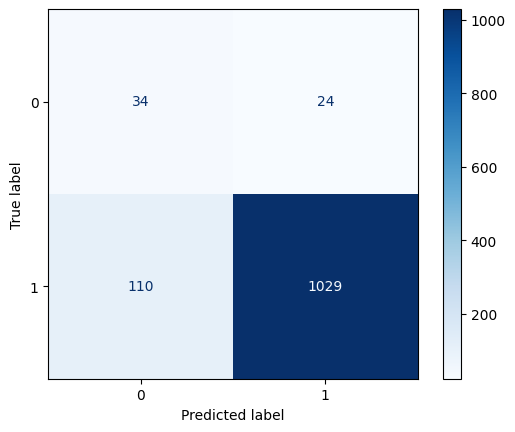

In [12]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test,
    cmap="Blues"
)
plt.show()


In [13]:
noisy_data.to_csv("Online_Exam_Malpractice_Prevention_System.csv", index=False)

In [14]:
import joblib

# Save the best model
joblib.dump(best_pipeline, "online_exam_malpractice_model.pkl")

# Load the saved model
model = joblib.load("online_exam_malpractice_model.pkl")

def predict_customer(data):
    prediction = model.predict(data)
    probability = model.predict_proba(data)
    return prediction, probability

In [15]:
sample = X_test.iloc[[0]]
print(predict_customer(sample))

(array([1], dtype=int32), array([[1.83423375e-04, 9.99816577e-01]]))


In [16]:
import joblib
joblib.dump(pipeline, "online_exam_malpractice_model.pkl")


['online_exam_malpractice_model.pkl']

In [17]:
import os
os.getcwd()


'c:\\Users\\admin\\OneDrive\\Desktop\\exam'